# SSP emissions runs using CMIP6 calibrations

This notebook gives an example of running the SSP scenarios in FaIR using pre-calculated climate response calibrations from 66 CMIP6 models for a total of 8 × 66 = 528 scenarios in parallel. We will run in stochastic mode to demonstrate internal variability.

This demonstrates the speed in which FaIR can run scenarios and configurations in parallel. This might be a good template notebook to use for SSP emissions-driven runs.

Refer to the `basic_emissions_run_example` for more detail on setting up a run step by step; this notebook will be a little lighter on the detail, but hopefully still enough to be useful.

## 0. import required modules

In [1]:
import numpy as np
import matplotlib.pyplot as pl
import pandas as pd

from fair import FAIR
from fair.io import read_properties
from fair.interface import fill, initialise
from fair.earth_params import seconds_per_year

/Users/sry/anaconda3/envs/fair/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. initialise FaIR

We want to enable the methane lifetime routine that is a function of SLCFs and reactive gases, i.e. using the coefficients and feedbacks from [Thornhill et al. 2021](https://acp.copernicus.org/articles/21/853/2021/acp-21-853-2021.html) and [Skeie et al. 2020](https://www.nature.com/articles/s41612-020-00131-0). We set this option in the initialiser this time.

In [2]:
f = FAIR(ch4_method='thornhill2021') # Thornhill (2021) methane lifetime scheme

## 2. Define time horizon

create world running from 1750 to 2100, at 1-year intervals

In [3]:
f.define_time(1750, 2100, 1) # Running time from 1750 to 2100, time step of 1 year

## 3. Define scenarios

We'll take the SSPs; important that the names are consistent with those in the RCMIP database

In [4]:
# Define SSP scenarios
# These scenario names must match the names used in the RCMIP database, because FaIR will later pull scenario-dependent emissions from that dataset.
scenarios = ['ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp434', 'ssp460', 'ssp534-over', 'ssp585']
f.define_scenarios(scenarios)

## 4. Define configs

Our list of configs are going to be each CMIP6 climate model's 4xCO2 response, which has been pre-calculated in the calibration notebooks.

We could also modify the response for different aerosol, ozone, methane lifetime tunings etc., but not every model has this data available.

In [5]:
# Read the pre-calculated CMIP6 climate-response calibrations.
# Each config represents one model/run combination, so FaIR can sample different climate responses in parallel instead of using only one parameter set.
df = pd.read_csv("../data/4xCO2_cummins_ebm3.csv")
models = df['model'].unique()
print(models)

configs = []

for imodel, model in enumerate(models):
    for run in df.loc[df['model']==model, 'run']:
        configs.append(f"{model}_{run}")
f.define_configs(configs)

<StringArray>
[    'CAMS-CSM1-0',     'GISS-E2-2-G',      'NorESM2-LM',   'ACCESS-ESM1-5',
 'HadGEM3-GC31-LL',           'CESM2',         'NorCPM1',           'CIESM',
       'INM-CM4-8',   'CNRM-CM6-1-HR',     'CESM2-WACCM',      'CAS-ESM2-0',
   'EC-Earth3-Veg',   'MPI-ESM1-2-HR',   'MPI-ESM1-2-LR',     'GISS-E2-1-G',
      'CNRM-CM6-1',     'GISS-E2-1-H',    'CMCC-CM2-SR5',      'MRI-ESM2-0',
     'SAM0-UNICON',       'EC-Earth3',    'IPSL-CM6A-LR',       'CESM2-FV2',
     'BCC-CSM2-MR',      'ACCESS-CM2',          'MIROC6',     'FIO-ESM-2-0',
 'CESM2-WACCM-FV2',        'BCC-ESM1', 'MPI-ESM-1-2-HAM',      'KACE-1-0-G',
       'GFDL-ESM4',     'UKESM1-0-LL',        'E3SM-1-0',       'KIOST-ESM',
        'IITM-ESM',        'GFDL-CM4',         'CanESM5',   'AWI-CM-1-1-MR',
       'INM-CM5-0',     'FGOALS-f3-L',       'FGOALS-g3',     'CNRM-ESM2-1',
         'TaiESM1',      'NorESM2-MM', 'HadGEM3-GC31-MM',           'NESM3',
      'MIROC-ES2L']
Length: 49, dtype: str


## 5. Define species and properties

FaIR contains a few helper functions that populate the model with sensible defaults. One is the `read_properties` function that obtains default species (the kitchen sink) and their properties for an emissions-driven run

In [6]:
species, properties = read_properties()
#species = list(properties.keys())

In [7]:
#species
#properties

In [8]:
species[:5]

['CO2 FFI', 'CO2 AFOLU', 'CO2', 'CH4', 'N2O']

In [9]:
properties['CO2 FFI']

{'type': 'co2 ffi',
 'input_mode': 'emissions',
 'greenhouse_gas': False,
 'aerosol_chemistry_from_emissions': False,
 'aerosol_chemistry_from_concentration': False}

In [10]:
f.define_species(species, properties) # Define the species and their properties in FaIR, using the properties read from the file.

## ~6. Modify run options~

Not required, because we set our run options in step 1.

## 7. Create input and output data

In [11]:
# Allocate memory for all FaIR input and output arrays after time, scenarios, configs, and species have been defined.
f.allocate()

## 8. Fill in the data

### 8a. get default species configs

Again we read in a default list of species configs that will apply to each config. If you want to change specific configs then you can still use this function to set defaults and tweak what you need. We will do this with the methane lifetime, which has a different value calibrated for the Thornhill 2021 lifetime option.

I'm also going to subtract the RCMIP 1750 emissions from CH4 and N2O. This is not in the default configs.

In [12]:
# Fill default species-specific parameter settings.
# Then adjust a few CH4 and N2O baseline values so the setup matches the chosen methane-lifetime parameterization more closely.
f.fill_species_configs()
fill(f.species_configs['unperturbed_lifetime'], 10.8537568, specie='CH4')
fill(f.species_configs['baseline_emissions'], 19.01978312, specie='CH4')
fill(f.species_configs['baseline_emissions'], 0.08602230754, specie='N2O')

### 8b. fill emissions

grab emissions (+solar and volcanic forcing) from RCMIP datasets using the `fill_from_rcmip` helper function. This function automatically selects the emissions, concentration or forcing you want depending on the `properties` for each of the SSP scenarios defined.

I'm then going to make one change: replace the volcanic dataset with the AR6 volcanic dataset, as I want to compare the impact of monthly volcanic forcing in the monthly comparison.

We also need to initialise the first timestep of the run in terms of its per-species forcing, temperature, cumulative and airborne emissions. We set these all to zero. The concentration in the first timestep will be set to the baseline concentration, which are the IPCC AR6 1750 values.

In [13]:
df_volcanic = pd.read_csv('../data/volcanic_ERF_monthly_175001-201912.csv', index_col='year')
df_volcanic[1750:].head()

,erf
year,
1895.833333,0.239388
1895.916667,0.241018
1896.000000,0.241199
1896.083333,0.241492
1896.166667,0.242317


In [14]:
f.fill_from_rcmip()

# # overwrite volcanic
# volcanic_forcing = np.zeros(351)
# volcanic_forcing[:271] = df_volcanic[1749:].groupby(np.ceil(df_volcanic[1749:].index) // 1).mean().squeeze().values
# fill(f.forcing, volcanic_forcing[:, None, None], specie="Volcanic")  # sometimes need to expand the array

# initialise(f.concentration, f.species_configs['baseline_concentration'])
# initialise(f.forcing, 0)
# initialise(f.temperature, 0)
# initialise(f.cumulative_emissions, 0)
# initialise(f.airborne_emissions, 0)

#-------- change --------------
# keep the default volcanic forcing from RCMIP to make the note book run first
initialise(f.concentration, f.species_configs['baseline_concentration'])
initialise(f.forcing, 0)
initialise(f.temperature, 0)
initialise(f.cumulative_emissions, 0)
initialise(f.airborne_emissions, 0)

### 8c. fill climate configs

Take pre-calculated values from the Cummins et al. three layer model. We will use a reproducible random seed to define the stochastic behaviour.

In [15]:
# Fill each climate configuration with pre-calculated response parameters derived from CMIP6-calibrated three-layer energy balance models.
df = pd.read_csv("../data/4xCO2_cummins_ebm3.csv")
models = df['model'].unique()

seed = 1355763

for config in configs:
    model, run = config.split('_')
    condition = (df['model']==model) & (df['run']==run)
    fill(f.climate_configs['ocean_heat_capacity'], df.loc[condition, 'C1':'C3'].values.squeeze(), config=config)
    fill(f.climate_configs['ocean_heat_transfer'], df.loc[condition, 'kappa1':'kappa3'].values.squeeze(), config=config)
    fill(f.climate_configs['deep_ocean_efficacy'], df.loc[condition, 'epsilon'].values[0], config=config)
    fill(f.climate_configs['gamma_autocorrelation'], df.loc[condition, 'gamma'].values[0], config=config)
    fill(f.climate_configs['sigma_eta'], df.loc[condition, 'sigma_eta'].values[0], config=config)
    fill(f.climate_configs['sigma_xi'], df.loc[condition, 'sigma_xi'].values[0], config=config)
    fill(f.climate_configs['stochastic_run'], True, config=config) # Stochastic variability is turned on so each config can include internal variability
    fill(f.climate_configs['use_seed'], True, config=config)
    fill(f.climate_configs['seed'], seed, config=config)
    
    seed = seed + 399

## 9. Run FaIR

look at it go.

You can turn off the progress bar with `progress=False`.

In [16]:
f.run()

Running 528 projections in parallel: 100%|██████████| 350/350 [00:02<00:00, 147.45timesteps/s]


## 10. Make some nice plots

Presently this is accessed using the `xarray` notation; perhaps we can write a nice filter function like I did with `fill` and `initialise`.

The output attributes of `FAIR` of interest are
- temperature (layer=0 is surface)
- emissions (an output for GHGs driven with concentration)
- concentration (as above, vice versa)
- forcing: the per-species effective radiative forcing
- forcing_sum: the total forcing
- airborne_emissions: total emissions of a GHG remaining in the atmosphere
- airborne_fraction: the fraction of GHG emissions remaining in the atmosphere
- alpha_lifetime: the scaling factor to unperturbed lifetime. Mutiply the two values to get the atmospheric lifetime of a greenhouse gas (see methane example below)
- cumulative_emissions
- ocean_heat_content_change
- toa_imbalance
- stochastic_forcing: if stochastic variability is activated, the non-deterministic part of the forcing

Text(0, 0.5, 'Temperature anomaly (K)')

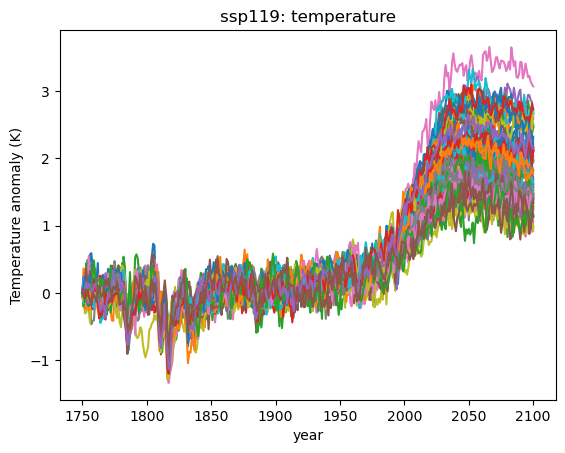

In [17]:
# Plot FaIR outputs for selected scenarios and species. Each colored line represents one climate configuration under the same SSP scenario.
pl.plot(f.timebounds, f.temperature.loc[dict(scenario='ssp119', layer=0)], label=f.configs); # layer 0 is surface temperature
pl.title('ssp119: temperature') 
pl.xlabel('year')
pl.ylabel('Temperature anomaly (K)') # SSP1-1.9; surface temperature anomaly

Text(0, 0.5, 'methane lifetime (yr)')

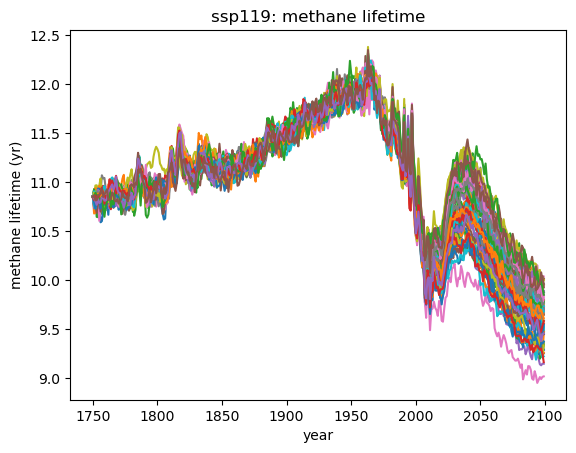

In [18]:
pl.plot(f.timebounds, f.species_configs['unperturbed_lifetime'].loc[dict(specie='CH4', gasbox=0)].data * f.alpha_lifetime.loc[dict(scenario='ssp119', specie='CH4')], label=f.configs);
pl.title('ssp119: methane lifetime')
pl.xlabel('year')
pl.ylabel('methane lifetime (yr)') # SSP1-1.9; CH4 lifetime in the atmosphere

Text(0, 0.5, 'W/m2')

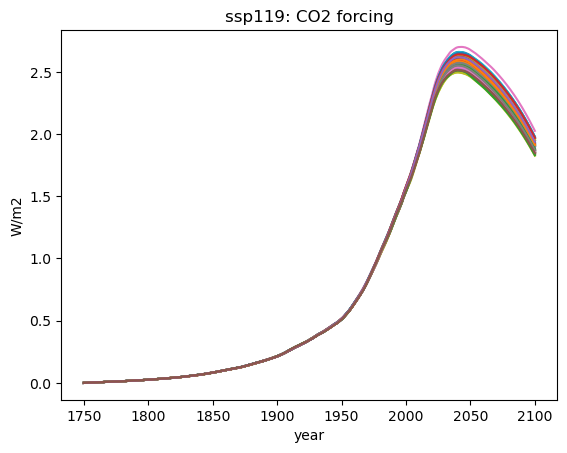

In [19]:
pl.plot(f.timebounds, f.forcing.loc[dict(scenario='ssp119', specie='CO2')], label=f.configs);
pl.title('ssp119: CO2 forcing')
pl.xlabel('year')
pl.ylabel('W/m2') # SSP1-1.9; effective radiative forcing from CO2

Text(0, 0.5, 'W/m2')

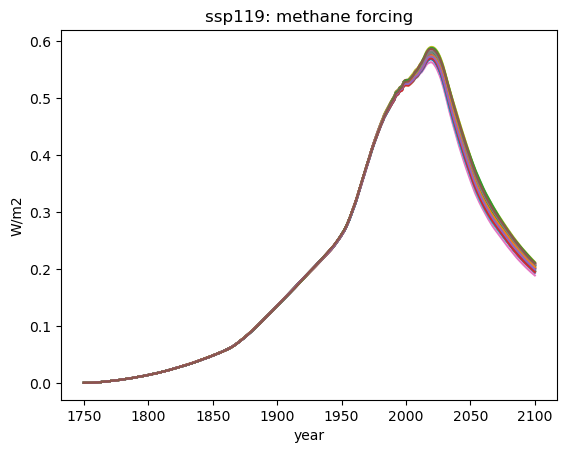

In [20]:
pl.plot(f.timebounds, f.forcing.loc[dict(scenario='ssp119', specie='CH4')], label=f.configs);
pl.title('ssp119: methane forcing')
pl.xlabel('year')
pl.ylabel('W/m2') # SSP1-1.9; effective radiative forcing from CH4

Text(0, 0.5, 'CH4 concentration (ppb)')

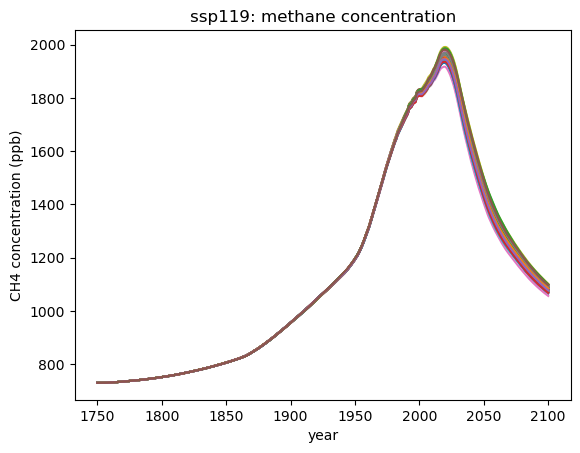

In [21]:
pl.plot(f.timebounds, f.concentration.loc[dict(scenario='ssp119', specie='CH4')], label=f.configs);
pl.title('ssp119: methane concentration')
pl.xlabel('year')
pl.ylabel('CH4 concentration (ppb)') # SSP1-1.9; atmospheric CH4 concentration in ppb

Text(0, 0.5, 'ppt')

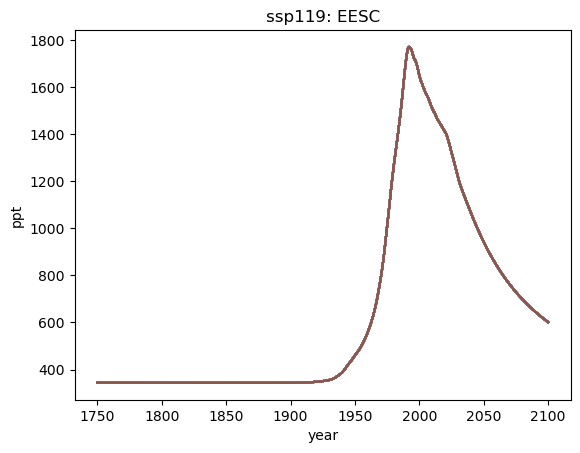

In [22]:
pl.plot(f.timebounds, f.concentration.loc[dict(scenario='ssp119', specie='Equivalent effective stratospheric chlorine')], label=f.configs);
pl.title('ssp119: EESC') # Equivalent Effective Stratospheric Chlorine (EESC)
pl.xlabel('year')
pl.ylabel('ppt') # SSP1-1.9; Equivalent effective stratospheric chlorine (EESC) in ppt

Text(0, 0.5, 'Effective radiative forcing (W m$^{-2}$)')

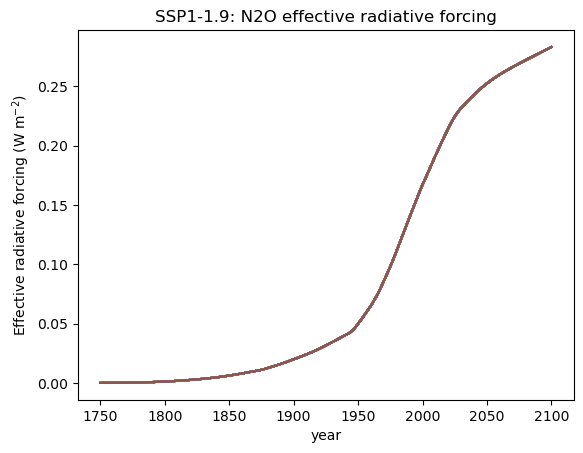

In [23]:
pl.plot(f.timebounds, f.forcing.loc[dict(scenario='ssp119', specie='N2O')], label=f.configs);
pl.title('SSP1-1.9: N2O effective radiative forcing')
pl.xlabel('year')
pl.ylabel('Effective radiative forcing (W m$^{-2}$)')

Text(0, 0.5, 'Effective radiative forcing (W m$^{-2}$)')

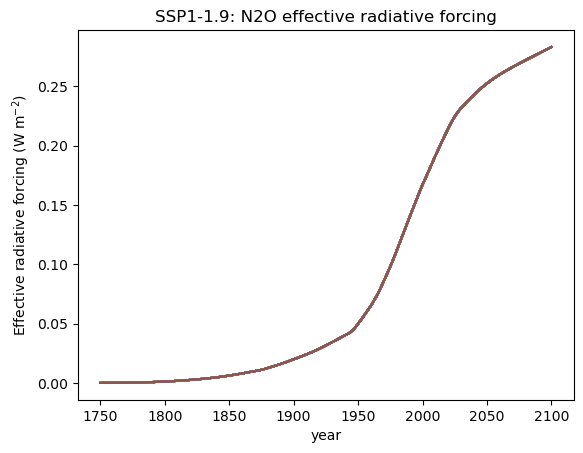

In [24]:
pl.plot(f.timebounds, f.forcing.loc[dict(scenario='ssp119', specie='N2O')], label=f.configs);
pl.title('SSP1-1.9: N2O effective radiative forcing')
pl.xlabel('year')
pl.ylabel('Effective radiative forcing (W m$^{-2}$)')

Text(0, 0.5, 'CH3Cl concentration (ppt)')

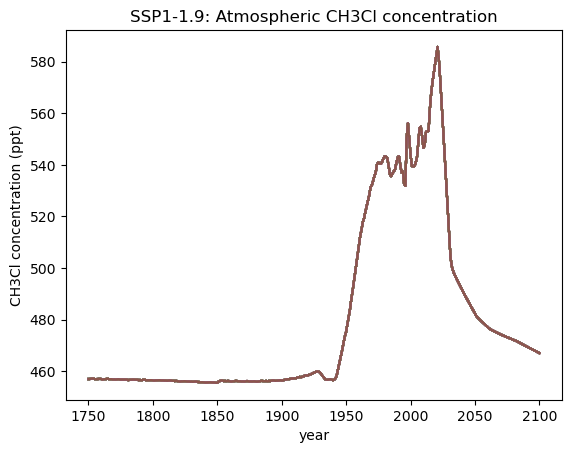

In [25]:
pl.plot(f.timebounds, f.concentration.loc[dict(scenario='ssp119', specie='CH3Cl')], label=f.configs);
pl.title('SSP1-1.9: Atmospheric CH3Cl concentration')
pl.xlabel('year')
pl.ylabel('CH3Cl concentration (ppt)')

Text(0, 0.5, 'W/m2')

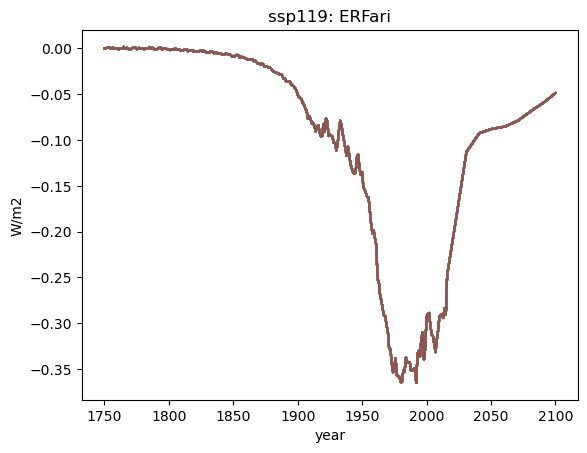

In [26]:
pl.plot(f.timebounds, f.forcing.loc[dict(scenario='ssp119', specie='Aerosol-radiation interactions')], label=f.configs);
pl.title('ssp119: ERFari') # Effective Radiative Forcing from Aerosol-Radiation Interactions (ERFari)
pl.xlabel('year')
pl.ylabel('W/m2') # SSP1-1.9; Effective Radiative Forcing from Aerosol-Radiation Interactions (ERFari) in W/m2

Text(0, 0.5, 'W/m2')

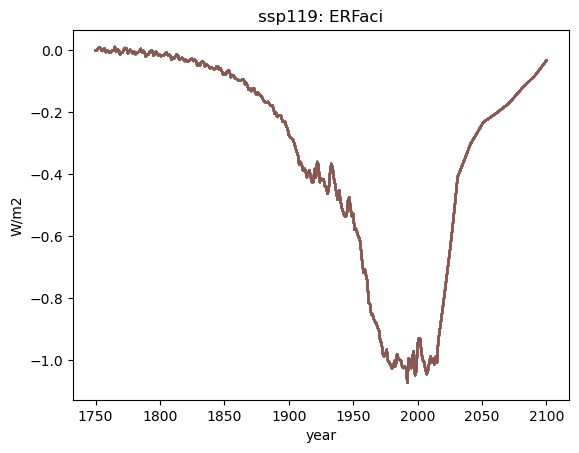

In [27]:
pl.plot(f.timebounds, f.forcing.loc[dict(scenario='ssp119', specie='Aerosol-cloud interactions')], label=f.configs);
pl.title('ssp119: ERFaci') # Effective Radiative Forcing from Aerosol-Cloud Interactions (ERFaci)
pl.xlabel('year')
pl.ylabel('W/m2') # SSP1-1.9; Effective Radiative Forcing from Aerosol-Cloud Interactions (ERFaci) in W/m2

Text(0, 0.5, 'W/m2')

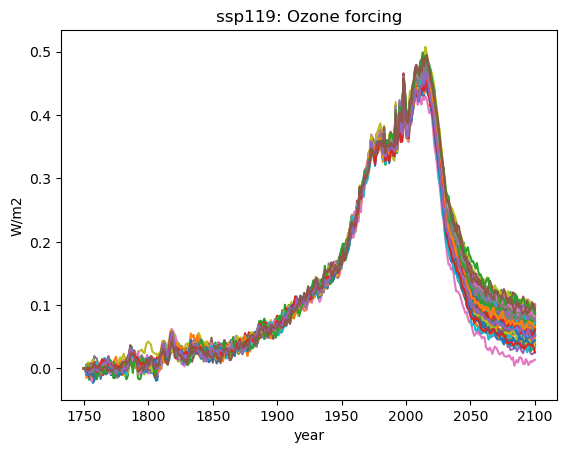

In [28]:
pl.plot(f.timebounds, f.forcing.loc[dict(scenario='ssp119', specie='Ozone')], label=f.configs);
pl.title('ssp119: Ozone forcing')
pl.xlabel('year')
pl.ylabel('W/m2') # SSP1-1.9; Effective Radiative Forcing from Ozone in W/m2

Text(0, 0.5, 'W/m2')

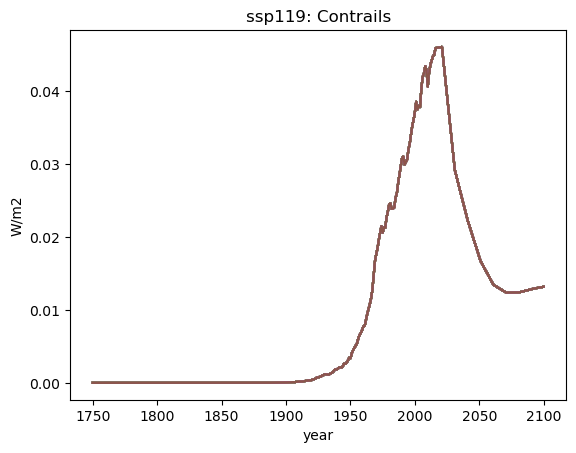

In [29]:
pl.plot(f.timebounds, f.forcing.loc[dict(scenario='ssp119', specie='Contrails')], label=f.configs);
pl.title('ssp119: Contrails')
pl.xlabel('year')
pl.ylabel('W/m2') # SSP1-1.9; Effective Radiative Forcing from Contrails in W/m2

Text(0, 0.5, 'W/m2')

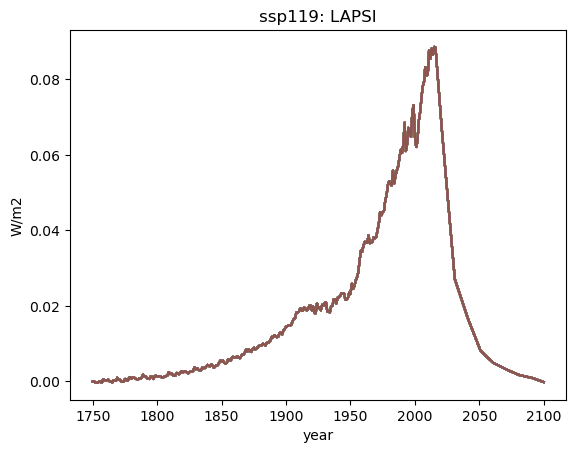

In [30]:
pl.plot(f.timebounds, f.forcing.loc[dict(scenario='ssp119', specie='Light absorbing particles on snow and ice')], label=f.configs);
pl.title('ssp119: LAPSI') # Effective Radiative Forcing from Light Absorbing Particles on Snow and Ice (LAPSI)
pl.xlabel('year')
pl.ylabel('W/m2') # SSP1-1.9; Effective Radiative Forcing from Light Absorbing Particles on Snow and Ice (LAPSI) in W/m2

Text(0, 0.5, 'W/m2')

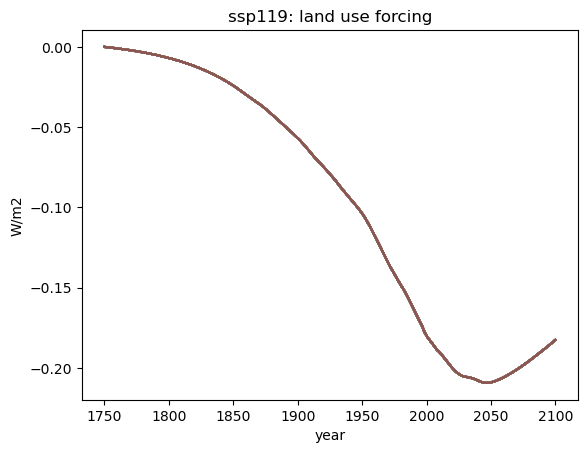

In [31]:
pl.plot(f.timebounds, f.forcing.loc[dict(scenario='ssp119', specie='Land use')], label=f.configs);
pl.title('ssp119: land use forcing')
pl.xlabel('year')
pl.ylabel('W/m2') # SSP1-1.9; Effective Radiative Forcing from Land Use in W/m2

Text(0, 0.5, 'W/m2')

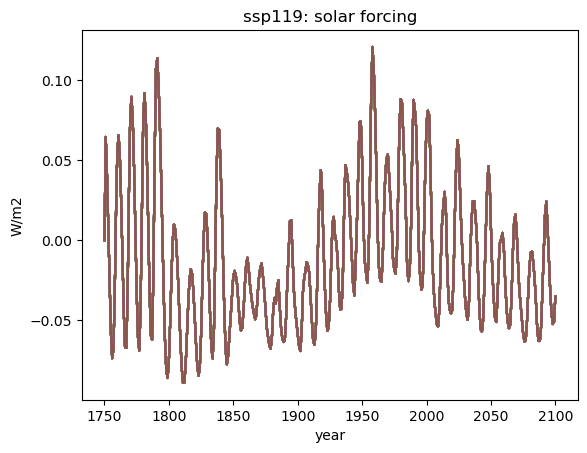

In [32]:
pl.plot(f.timebounds, f.forcing.loc[dict(scenario='ssp119', specie='Solar')], label=f.configs);
pl.title('ssp119: solar forcing')
pl.xlabel('year')
pl.ylabel('W/m2') # SSP1-1.9; Effective Radiative Forcing from Solar Variations in W/m2

Text(0, 0.5, 'W/m2')

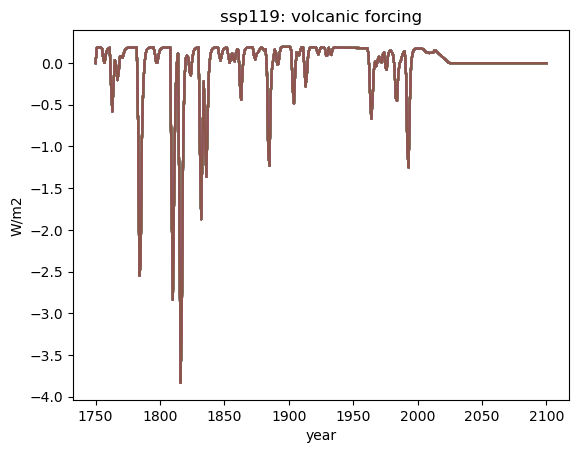

In [33]:
pl.plot(f.timebounds, f.forcing.loc[dict(scenario='ssp119', specie='Volcanic')], label=f.configs);
pl.title('ssp119: volcanic forcing')
pl.xlabel('year')
pl.ylabel('W/m2') # SSP1-1.9; Effective Radiative Forcing from Volcanic Activity in W/m2

Text(0, 0.5, 'W/m2')

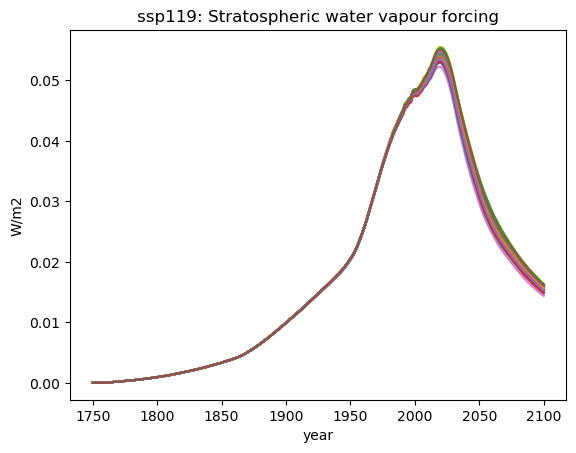

In [34]:
pl.plot(f.timebounds, f.forcing.loc[dict(scenario='ssp119', specie='Stratospheric water vapour')], label=f.configs);
pl.title('ssp119: Stratospheric water vapour forcing')
pl.xlabel('year')
pl.ylabel('W/m2') # SSP1-1.9; Effective Radiative Forcing from Stratospheric Water Vapour in W/m2

Text(0, 0.5, 'Temperature anomaly (K)')

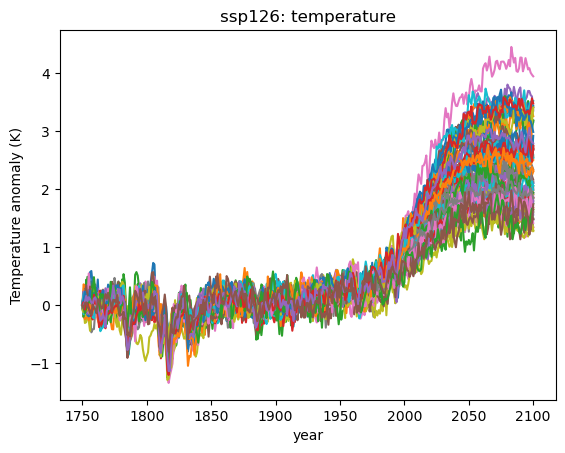

In [35]:
pl.plot(f.timebounds, f.temperature.loc[dict(scenario='ssp126', layer=0)], label=f.configs);
pl.title('ssp126: temperature')
pl.xlabel('year')
pl.ylabel('Temperature anomaly (K)') # SSP1-2.6; surface temperature anomaly
#pl.legend()

Text(0, 0.5, 'Temperature anomaly (K)')

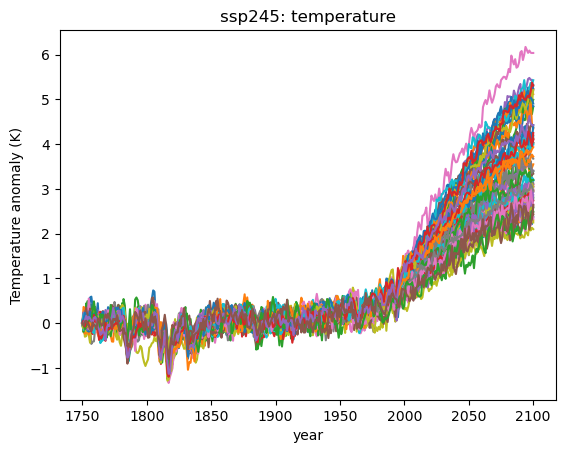

In [36]:
pl.plot(f.timebounds, f.temperature.loc[dict(scenario='ssp245', layer=0)], label=f.configs);
pl.title('ssp245: temperature')
pl.xlabel('year')
pl.ylabel('Temperature anomaly (K)') # SSP2-4.5; surface temperature anomaly
#pl.legend()

Text(0, 0.5, 'Temperature anomaly (K)')

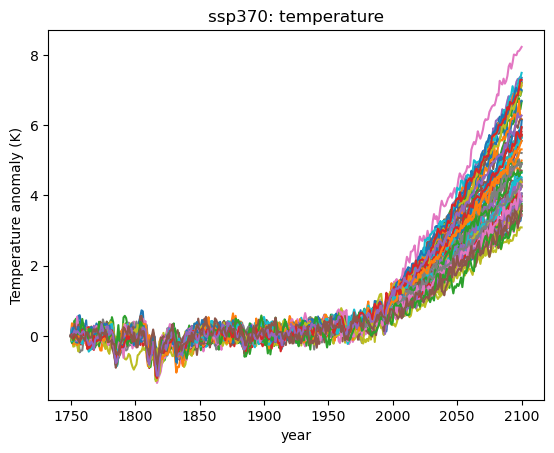

In [37]:
pl.plot(f.timebounds, f.temperature.loc[dict(scenario='ssp370', layer=0)], label=f.configs);
pl.title('ssp370: temperature')
pl.xlabel('year')
pl.ylabel('Temperature anomaly (K)') # SSP3-7.0; surface temperature anomaly
#pl.legend()

Text(0, 0.5, 'Temperature anomaly (K)')

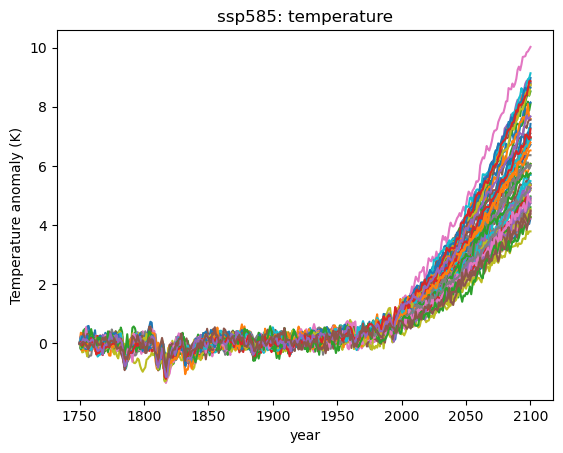

In [38]:
pl.plot(f.timebounds, f.temperature.loc[dict(scenario='ssp585', layer=0)], label=f.configs);
pl.title('ssp585: temperature')
pl.xlabel('year')
pl.ylabel('Temperature anomaly (K)') # SSP5-8.5; surface temperature anomaly
#pl.legend()

Text(0, 0.5, 'W/m2')

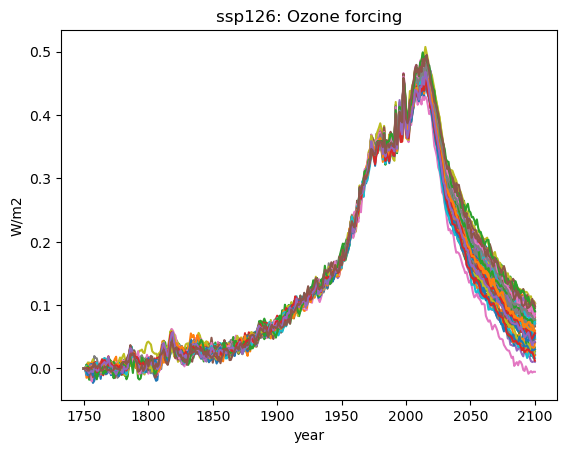

In [39]:
pl.plot(f.timebounds, f.forcing.loc[dict(scenario='ssp126', specie='Ozone')], label=f.configs);
pl.title('ssp126: Ozone forcing')
pl.xlabel('year')
pl.ylabel('W/m2') # SSP1-2.6; Effective Radiative Forcing from Ozone in W/m2

Text(0, 0.5, 'W/m2')

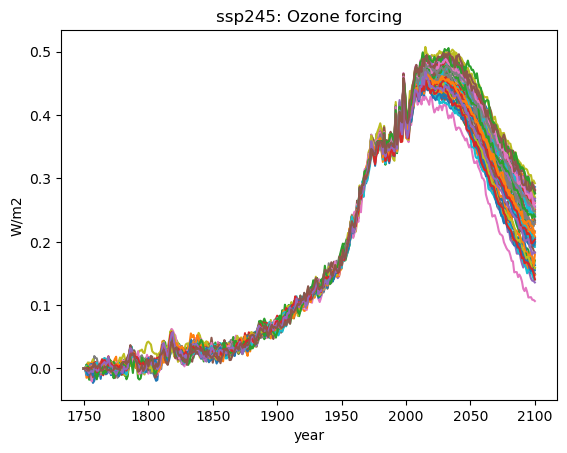

In [40]:
pl.plot(f.timebounds, f.forcing.loc[dict(scenario='ssp245', specie='Ozone')], label=f.configs);
pl.title('ssp245: Ozone forcing')
pl.xlabel('year')
pl.ylabel('W/m2') # SSP2-4.5; Effective Radiative Forcing from Ozone in W/m2

Text(0, 0.5, 'W/m2')

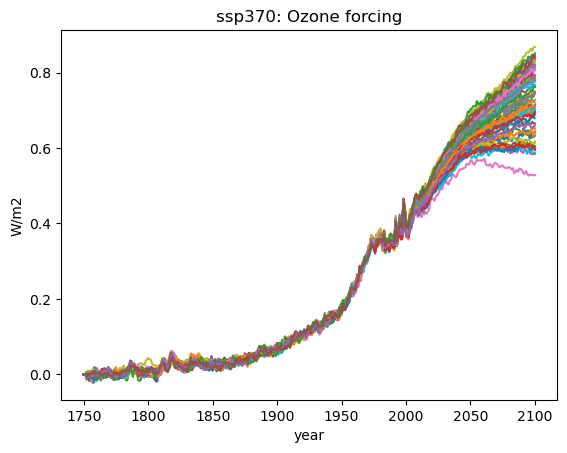

In [41]:
pl.plot(f.timebounds, f.forcing.loc[dict(scenario='ssp370', specie='Ozone')], label=f.configs);
pl.title('ssp370: Ozone forcing')
pl.xlabel('year')
pl.ylabel('W/m2') # SSP3-7.0; Effective Radiative Forcing from Ozone in W/m2

Text(0, 0.5, 'W/m2')

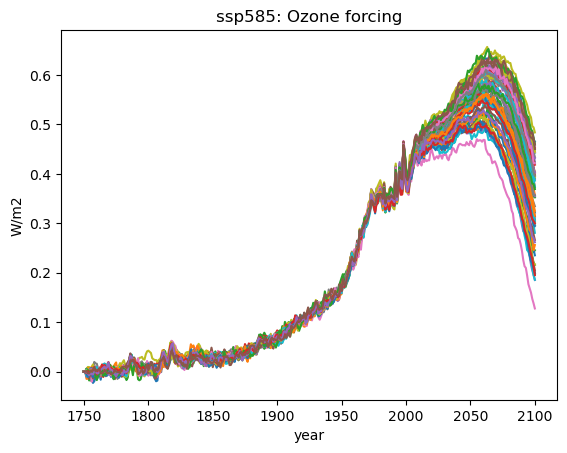

In [42]:
pl.plot(f.timebounds, f.forcing.loc[dict(scenario='ssp585', specie='Ozone')], label=f.configs);
pl.title('ssp585: Ozone forcing')
pl.xlabel('year')
pl.ylabel('W/m2') # SSP5-8.5; Effective Radiative Forcing from Ozone in W/m2

Text(0, 0.5, 'GtCO2')

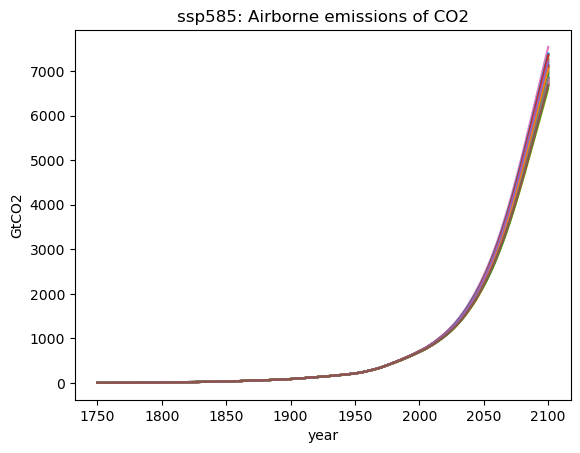

In [43]:
pl.plot(f.timebounds, f.airborne_emissions.loc[dict(scenario='ssp585', specie='CO2')], label=f.configs);
pl.title('ssp585: Airborne emissions of CO2')
pl.xlabel('year')
pl.ylabel('GtCO2') # SSP5-8.5; Airborne emissions of CO2 in GtCO2/yr

Text(0, 0.5, '[1]')

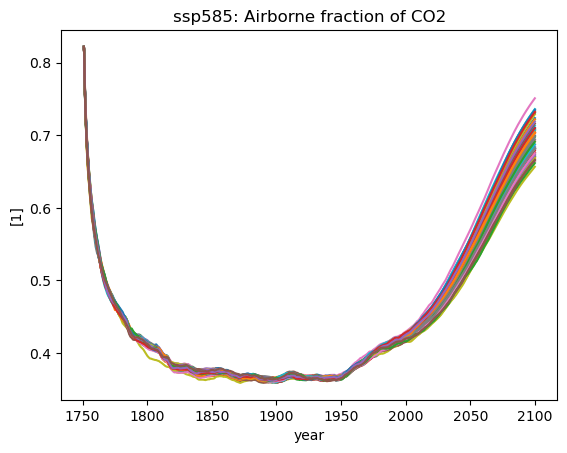

In [44]:
pl.plot(f.timebounds, f.airborne_fraction.loc[dict(scenario='ssp585', specie='CO2')], label=f.configs);
pl.title('ssp585: Airborne fraction of CO2')
pl.xlabel('year')
pl.ylabel('[1]') # SSP5-8.5; Airborne fraction of CO2 (dimensionless)

Text(0, 0.5, 'GtCO2')

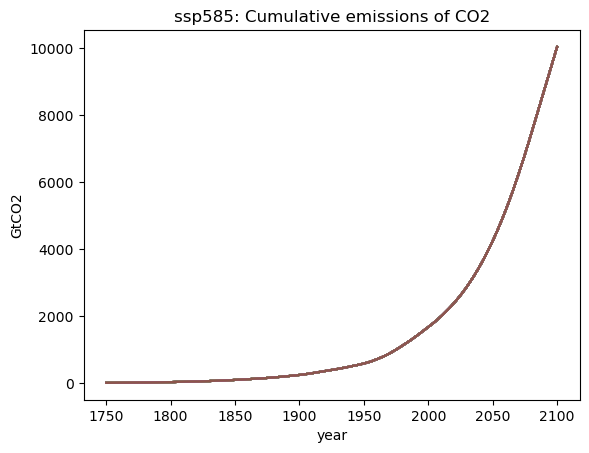

In [45]:
pl.plot(f.timebounds, f.cumulative_emissions.loc[dict(scenario='ssp585', specie='CO2')], label=f.configs);
pl.title('ssp585: Cumulative emissions of CO2')
pl.xlabel('year')
pl.ylabel('GtCO2') # SSP5-8.5; Cumulative emissions of CO2 in GtCO2

Text(0, 0.5, 'J')

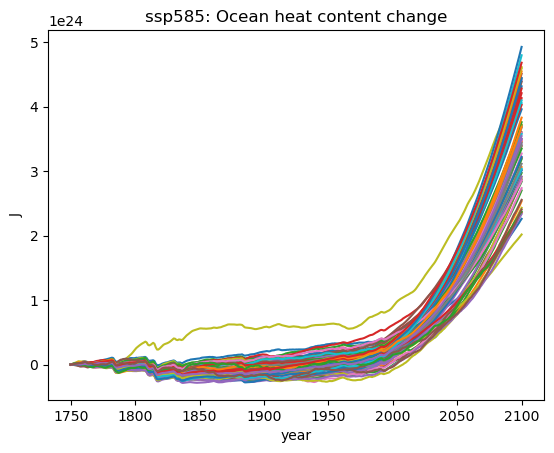

In [46]:
pl.plot(f.timebounds, f.ocean_heat_content_change.loc[dict(scenario='ssp585')], label=f.configs);
pl.title('ssp585: Ocean heat content change')
pl.xlabel('year')
pl.ylabel('J') # SSP5-8.5; Ocean heat content change in Joules

Text(0, 0.5, 'W m$^{-2}$')

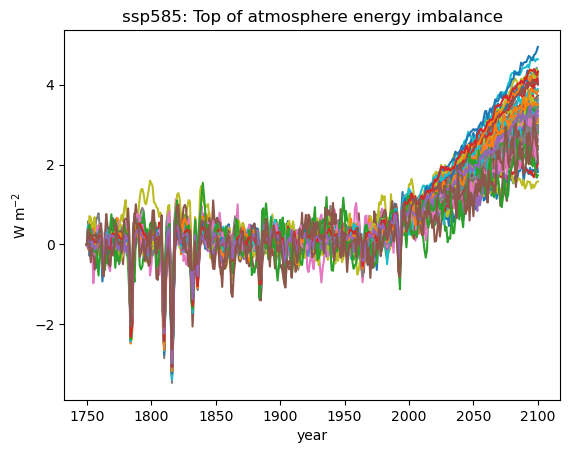

In [47]:
pl.plot(f.timebounds, f.toa_imbalance.loc[dict(scenario='ssp585')], label=f.configs);
pl.title('ssp585: Top of atmosphere energy imbalance')
pl.xlabel('year')
pl.ylabel('W m$^{-2}$') # SSP5-8.5; Top of atmosphere energy imbalance in W/m2

Text(0, 0.5, 'W m$^{-2}$')

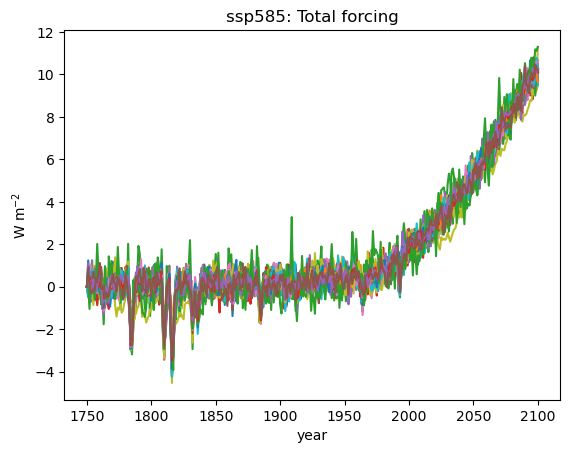

In [48]:
pl.plot(f.timebounds, f.stochastic_forcing.loc[dict(scenario='ssp585')], label=f.configs);
pl.title('ssp585: Total forcing')
pl.xlabel('year')
pl.ylabel('W m$^{-2}$') # SSP5-8.5; Total forcing (including stochastic variability) in W/m2

Text(0, 0.5, 'W m$^{-2}$')

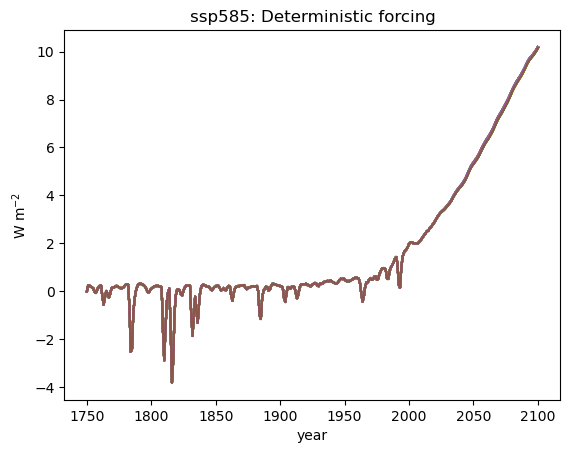

In [49]:
pl.plot(f.timebounds, f.forcing_sum.loc[dict(scenario='ssp585')], label=f.configs);
pl.title('ssp585: Deterministic forcing')
pl.xlabel('year')
pl.ylabel('W m$^{-2}$') # SSP5-8.5; Deterministic forcing (excluding stochastic variability) in W/m2

Text(0, 0.5, 'W m$^{-2}$')

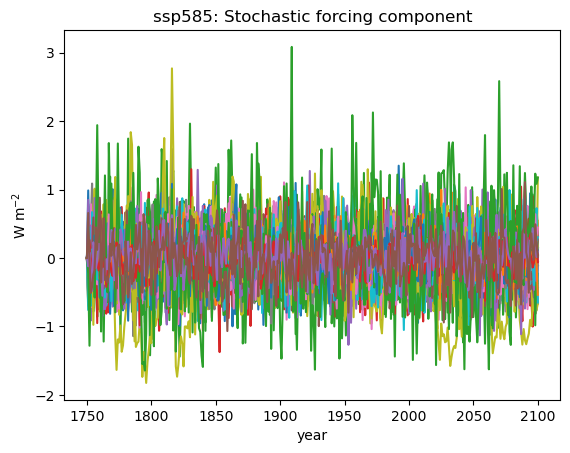

In [50]:
pl.plot(f.timebounds, f.stochastic_forcing.loc[dict(scenario='ssp585')]-f.forcing_sum.loc[dict(scenario='ssp585')], label=f.configs);
pl.title('ssp585: Stochastic forcing component')
pl.xlabel('year')
pl.ylabel('W m$^{-2}$') # SSP5-8.5; Stochastic forcing component in W/m2

------
## Reproducing the figure of global warming under different emission scenarios from class with FaIR

This figure is an FaIR-based analogue of the course slide based on IPCC AR5 WGI Chapter 12 Figure 12.5.  
The original course figure shows global annual mean surface air temperature anomalies relative to 1986–2005 from CMIP5 concentration-driven RCP experiments, with the multi-model mean shown as solid lines and the 5–95% range shown as shading.  
The FaIR version is not an exact duplicate, because it uses SSP scenarios and CMIP6-calibrated FaIR configurations rather than CMIP5 RCP simulations.  

However, it is designed to reproduce the same main visual message: different forcing scenarios give similar near-term warming but diverge more strongly later in the century.

In [51]:
# Reproduce the structure of the course figure using FaIR output
# Original slide: CMIP5 + RCPs + multi-model mean + 5-95% range
# This project: FaIR + SSPs + CMIP6-calibrated configs + 5-95% range

# Use SSPs that are closest in forcing level to the RCPs in the course slide
scenario_map = {
    "ssp126": "SSP1-2.6",
    "ssp245": "SSP2-4.5",
    "ssp460": "SSP4-6.0",
    "ssp585": "SSP5-8.5",
}

# Colors chosen to resemble the slide structure
scenario_colors = {
    "ssp126": "blue",
    "ssp245": "cornflowerblue",
    "ssp460": "peru",
    "ssp585": "red",
}

# Convert time axis to NumPy array for easier numerical operations
years = np.asarray(f.timebounds)
#years

In [52]:
def temp_anomaly_rel_1986_2005(scenario):
    """
    Return surface temperature anomaly for one scenario,
    rebased to the 1986-2005 mean, matching the course figure convention.
    Output dimensions: timebounds x config
    """
    # Set surface temperature (layer 0) for one scenario, then reorder dimensions so time is the first axis and config is the second.
    da = f.temperature.loc[dict(scenario=scenario, layer=0)].transpose("timebounds", "config")
    baseline = da.sel(timebounds=slice(1986, 2005)).mean(dim="timebounds")
    return da - baseline # create anomalies relative to 1986-2005

# Historical part: use one scenario before branching because SSPs share the same historical pathway
hist_da = temp_anomaly_rel_1986_2005("ssp245")     

hist_mean = hist_da.mean(dim="config")              # mean historical temperature
hist_p05 = hist_da.quantile(0.05, dim="config")     # lower bound (5th percentile) of the historical temperature
hist_p95 = hist_da.quantile(0.95, dim="config")     # upper bound (95th percentile) of the historical temperature

hist_mask = years <= 2014
future_mask = years >= 2015

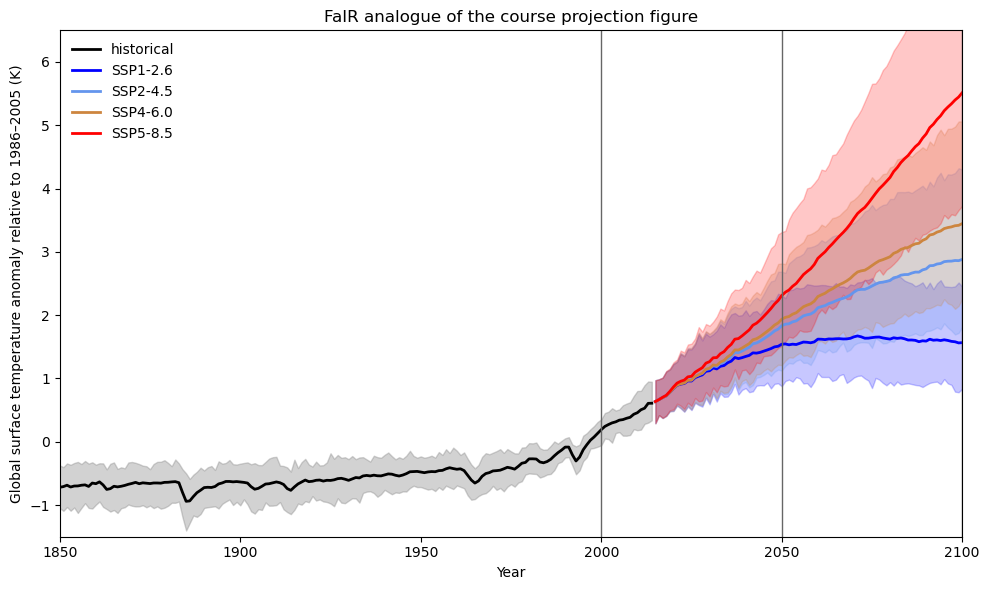

In [53]:
pl.figure(figsize=(10, 6))
# Plot the historical 5-95% range as a gray shaded envelope.
pl.fill_between(
    years[hist_mask],
    hist_p05.values[hist_mask],
    hist_p95.values[hist_mask],
    color="gray",
    alpha=0.35,
)
# Plot the historical mean as a solid black line.
pl.plot(
    years[hist_mask],
    hist_mean.values[hist_mask],
    color="black",
    linewidth=2,
    label="historical",
)

# Future scenarios: mean + 5-95% range
for scenario, label in scenario_map.items():
    # Get the rebased temperature anomaly for the current scenario.
    da = temp_anomaly_rel_1986_2005(scenario)
    mean = da.mean(dim="config")
    p05 = da.quantile(0.05, dim="config")
    p95 = da.quantile(0.95, dim="config")
    # Plot the 5-95% uncertainty band for the scenario as a semi-transparent fill.
    pl.fill_between(
        years[future_mask],
        p05.values[future_mask],
        p95.values[future_mask],
        color=scenario_colors[scenario],
        alpha=0.22, # transparency level for the fill
    )
    # Plot the mean scenario trajectory as a colored line.
    pl.plot(
        years[future_mask],
        mean.values[future_mask],
        color=scenario_colors[scenario],
        linewidth=2,
        label=label,
    )

# Add vertical guide lines to roughly mimic the time markers in the course figure.
pl.axvline(2000, color="0.4", linewidth=1)
pl.axvline(2100, color="0.4", linewidth=1)
pl.axvline(2050, color="0.4", linewidth=1)


pl.xlim(1850, 2100)
pl.ylim(-1.5, 6.5)
pl.xlabel("Year")
pl.ylabel("Global surface temperature anomaly relative to 1986–2005 (K)")
pl.title("FaIR analogue of the course projection figure")
pl.legend(frameon=False)
pl.tight_layout()
pl.show()

In [54]:
# Quantify scenario outcomes in 2050 and 2100
scenario_map = {
    "ssp126": "SSP1-2.6",
    "ssp245": "SSP2-4.5",
    "ssp460": "SSP4-6.0",
    "ssp585": "SSP5-8.5",
}

target_years = [2000, 2050, 2100]
rows = []

In [55]:
for scenario, label in scenario_map.items():
    da = temp_anomaly_rel_1986_2005(scenario)  # timebounds x config

    for year in target_years:
        # Select the requested year
        vals = da.sel(timebounds=year).values  # one value per config

        mean_val = np.mean(vals)
        p05_val = np.quantile(vals, 0.05)
        p95_val = np.quantile(vals, 0.95)

        rows.append({
            "Scenario": label,
            "Year": year,
            "Mean warming (K)": mean_val,
            "5th percentile (K)": p05_val,
            "95th percentile (K)": p95_val,
        })

summary_df = pd.DataFrame(rows)
summary_df

,Scenario,Year,Mean warming (K),5th percentile (K),95th percentile (K)
0,SSP1-2.6,2000,0.191362,-0.055317,0.354337
1,SSP1-2.6,2050,1.541316,0.877320,2.314302
2,SSP1-2.6,2100,1.566083,0.837521,2.449368
3,SSP2-4.5,2000,0.191362,-0.055317,0.354337
4,SSP2-4.5,2050,1.832927,1.124537,2.687238
5,SSP2-4.5,2100,2.880419,1.815701,4.299807
6,SSP4-6.0,2000,0.191362,-0.055317,0.354337
7,SSP4-6.0,2050,1.935771,1.211266,2.817723
8,SSP4-6.0,2100,3.447194,2.258884,5.060806
9,SSP5-8.5,2000,0.191362,-0.055317,0.354337


In [56]:
# Round for cleaner presentation
summary_df = summary_df.round({
    "Mean warming (K)": 2,
    "5th percentile (K)": 2,
    "95th percentile (K)": 2,
})

summary_df

,Scenario,Year,Mean warming (K),5th percentile (K),95th percentile (K)
0,SSP1-2.6,2000,0.19,-0.06,0.35
1,SSP1-2.6,2050,1.54,0.88,2.31
2,SSP1-2.6,2100,1.57,0.84,2.45
3,SSP2-4.5,2000,0.19,-0.06,0.35
4,SSP2-4.5,2050,1.83,1.12,2.69
5,SSP2-4.5,2100,2.88,1.82,4.30
6,SSP4-6.0,2000,0.19,-0.06,0.35
7,SSP4-6.0,2050,1.94,1.21,2.82
8,SSP4-6.0,2100,3.45,2.26,5.06
9,SSP5-8.5,2000,0.19,-0.06,0.35


### Comparison between the course figure and my FaIR reproduction

The course figure is based on IPCC AR5 WGI Chapter 12, Figure 12.5, which shows time series of global annual mean surface air temperature anomalies relative to 1986–2005 from CMIP5 concentration-driven experiments. In that figure, the projections are shown for the multi-model mean as solid lines, and the 5–95% range across models is shown as shading. The caption also notes that the original figure extends beyond 2100 using extension runs beyond the 21st century.

In contrast, my project uses FaIR, which was introduced in class as “a simple climate model (‘emulator’)” rather than a full general circulation model. The goal of this project is therefore not to reproduce the original IPCC figure exactly, but to build a FaIR-based analogue that reproduces its main structure and scientific message.

RCPs (Representative Concentration Pathways) are climate scenario pathways defined by their radiative forcing characteristics.
SSPs (Shared Socioeconomic Pathways) are scenarios describing possible future developments in society, the economy, population, and technology.

Limited to 2100: In my notebook, the FaIR run was explicitly defined with: ‘f.define_time(1750, 2100, 1)’
so the model itself only runs from 1750 to 2100 at annual resolution. In the reproduction figure, I then plotted only 1850 to 2100 using the x-axis limits. By contrast, the course figure extends past 2100 because the original IPCC figure includes extension runs beyond the 21st century.

Result:
My FaIR figure shows global surface temperature anomaly relative to 1986–2005 from 1850 to 2100. The black line represents the historical mean, and the colored future lines represent the mean trajectories for SSP1-2.6, SSP2-4.5, SSP4-6.0, and SSP5-8.5. The shaded regions show the spread across FaIR configurations, represented here by the 5th to 95th percentile range. This makes the figure directly comparable in structure to the course figure, even though it is based on a different model framework.

This project reproduce the course figure in overall trend but not an exact reproduction. The warming trajectories are relatively similar in the near term, but the differences among scenarios become much larger later in the century. That matches the class discussion that forced response dominates uncertainty for the first ~50 years, while emissions scenario dominates uncertainty beyond ~50 years.

Differences between models:
* The course figure is based on CMIP5 and RCPs, while my figure is based on FaIR, SSPs, and CMIP6-calibrated FaIR configurations.

* The course figure uses spread across individual CMIP5 models, whereas my figure uses spread across FaIR configurations, with stochastic variability also included in the notebook setup.

* The course figure extends to 2300, while my notebook currently stops at 2100.

* Because FaIR is a reduced-complexity emulator, it is designed to efficiently reproduce large-scale global temperature behavior, not to exactly duplicate every feature of the original GCM ensemble figure

### Interpretation of the quantitative results

The quantitative table is consistent with the visual pattern in the FaIR reproduction figure. In 2000, all scenarios have the same projected anomaly because they still share the historical pathway and have not yet diverged into different future forcing trajectories. By 2100, however, the differences among scenarios become very large. SSP1-2.6 reaches a mean warming of 1.57 K, while SSP5-8.5 reaches 5.52 K, with SSP2-4.5 and SSP4-6.0 falling in between. This confirms the main message of the course figure: scenario differences are much more important later in the century than earlier in the record. The uncertainty ranges also widen substantially by 2100, especially for the higher-forcing pathways. This means that both the central estimate and the spread increase under stronger forcing, but the dominant visual result is still the strong separation among scenario means by the end of the century.

## Custom forcing experiment: reduced fossil-fuel CO2 emissions

In this experiment, I use SSP2-4.5 as the baseline scenario and create a modified version in which fossil-fuel-and-industry CO2 emissions (CO2 FFI) are reduced by 50% starting in 2030. The goal is to test how much projected global warming changes when a simple emissions reduction is imposed relative to the baseline pathway.

In [57]:
def run_ssp245_experiment(cut_year=None, reduction_fraction=0.5):
    """
    Run FaIR for SSP2-4.5.
    
    Parameters
    ----------
    cut_year : int or None
        If not None, reduce CO2 FFI emissions from this year onward.
    reduction_fraction : float
        Fractional reduction in CO2 FFI emissions after cut_year.
        Example: 0.5 means a 50% reduction.
    
    Returns
    -------
    f_exp : FAIR
        The completed FaIR experiment object.
    """
    
    f_exp = FAIR(ch4_method='thornhill2021')
    f_exp.define_time(1750, 2100, 1)
    # Use only SSP2-4.5
    scenarios = ['ssp245']
    f_exp.define_scenarios(scenarios)
    # Define CMIP6-calibrated configs
    df_configs = pd.read_csv("../data/4xCO2_cummins_ebm3.csv")
    models = df_configs['model'].unique()
    configs = []

    for model in models:
        for run in df_configs.loc[df_configs['model'] == model, 'run']:
            configs.append(f"{model}_{run}")

    f_exp.define_configs(configs)
    species, properties = read_properties()
    f_exp.define_species(species, properties)
    f_exp.allocate()
    
    # Fill default species configs, same as before
    f_exp.fill_species_configs()
    fill(f_exp.species_configs['unperturbed_lifetime'], 10.8537568, specie='CH4')
    fill(f_exp.species_configs['baseline_emissions'], 19.01978312, specie='CH4')
    fill(f_exp.species_configs['baseline_emissions'], 0.08602230754, specie='N2O')
    
    # Load scenario data from RCMIP
    f_exp.fill_from_rcmip()
    
    # Initialise state variables, same as before
    initialise(f_exp.concentration, f_exp.species_configs['baseline_concentration'])
    initialise(f_exp.forcing, 0)
    initialise(f_exp.temperature, 0)
    initialise(f_exp.cumulative_emissions, 0)
    initialise(f_exp.airborne_emissions, 0)
    
    # Fill climate configs, same as before
    seed = 1355763
    
    for config in configs:
        model, run = config.split('_')
        condition = (df_configs['model'] == model) & (df_configs['run'] == run)
        
        fill(f_exp.climate_configs['ocean_heat_capacity'],
             df_configs.loc[condition, 'C1':'C3'].values.squeeze(), config=config)
        fill(f_exp.climate_configs['ocean_heat_transfer'],
             df_configs.loc[condition, 'kappa1':'kappa3'].values.squeeze(), config=config)
        fill(f_exp.climate_configs['deep_ocean_efficacy'],
             df_configs.loc[condition, 'epsilon'].values[0], config=config)
        fill(f_exp.climate_configs['gamma_autocorrelation'],
             df_configs.loc[condition, 'gamma'].values[0], config=config)
        fill(f_exp.climate_configs['sigma_eta'],
             df_configs.loc[condition, 'sigma_eta'].values[0], config=config)
        fill(f_exp.climate_configs['sigma_xi'],
             df_configs.loc[condition, 'sigma_xi'].values[0], config=config)
        fill(f_exp.climate_configs['stochastic_run'], True, config=config)
        fill(f_exp.climate_configs['use_seed'], True, config=config)
        fill(f_exp.climate_configs['seed'], seed, config=config)
        
        seed += 399
    
    # Test: reduce CO2 FFI after cut_year, FFI = fossil fuel and industrial CO2 emissions
    if cut_year is not None:
        time_dim = 'timepoints' if 'timepoints' in f_exp.emissions.dims else 'timebounds'
        
        selector = {
            time_dim: slice(cut_year, None),
            'scenario': 'ssp245',
            'specie': 'CO2 FFI'
        }
        
        f_exp.emissions.loc[selector] = (
            f_exp.emissions.loc[selector] * (1 - reduction_fraction)
        )
    
    f_exp.run()
    
    return f_exp

In [58]:
cut_year = 2030 # intervention year 

# Run baseline
f_base = run_ssp245_experiment(cut_year=None, reduction_fraction=0.5) # 0.5 means a 50% reduction in CO2 FFI emissions after 2030

Running 66 projections in parallel: 100%|██████████| 350/350 [00:00<00:00, 409.52timesteps/s]


In [59]:
# Run modified experiment with CO2 FFI reductions starting from cut_year
f_cut  = run_ssp245_experiment(cut_year=cut_year, reduction_fraction=0.5)

Running 66 projections in parallel: 100%|██████████| 350/350 [00:00<00:00, 564.37timesteps/s]


In [60]:
def temp_anomaly_rel_1986_2005_from_model(f_model, scenario='ssp245'):
    """
    Return surface temperature anomaly relative to the 1986-2005 mean
    for one FaIR model object and one scenario.
    """
    da = f_model.temperature.loc[dict(scenario=scenario, layer=0)].transpose("timebounds", "config")
    baseline = da.sel(timebounds=slice(1986, 2005)).mean(dim="timebounds")
    return da - baseline

In [61]:
years_base = np.asarray(f_base.timebounds)

da_base = temp_anomaly_rel_1986_2005_from_model(f_base, 'ssp245')
da_cut  = temp_anomaly_rel_1986_2005_from_model(f_cut,  'ssp245')

base_mean = da_base.mean(dim='config')
base_p05  = da_base.quantile(0.05, dim='config')
base_p95  = da_base.quantile(0.95, dim='config')

cut_mean = da_cut.mean(dim='config')
cut_p05  = da_cut.quantile(0.05, dim='config')
cut_p95  = da_cut.quantile(0.95, dim='config')

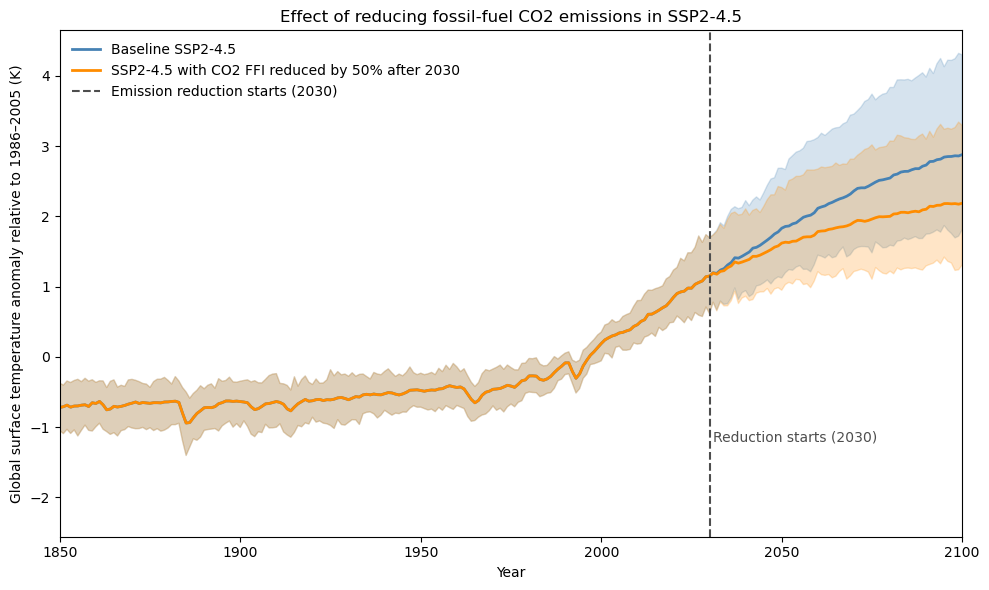

In [62]:
pl.figure(figsize=(10, 6))

# Baseline SSP2-4.5
pl.fill_between(
    years_base,
    base_p05.values,
    base_p95.values,
    color='steelblue',
    alpha=0.22, # transparency level for the fill
)
pl.plot(
    years_base,
    base_mean.values,
    color='steelblue',
    linewidth=2,
    label='Baseline SSP2-4.5',
)

# Modified SSP2-4.5
pl.fill_between(
    years_base,
    cut_p05.values,
    cut_p95.values,
    color='darkorange',
    alpha=0.22,
)
pl.plot(
    years_base,
    cut_mean.values,
    color='darkorange',
    linewidth=2,
    label=f'SSP2-4.5 with CO2 FFI reduced by 50% after {cut_year}',
)

pl.axvline(cut_year, color='0.3', linestyle='--', linewidth=1.5, label=f'Emission reduction starts ({cut_year})')
pl.text(cut_year + 1, -1.2, f'Reduction starts ({cut_year})', color='0.3') # -1.2 is a y-coordinate chosen to place the text below the lines
pl.xlim(1850, 2100)
pl.xlabel("Year")
pl.ylabel("Global surface temperature anomaly relative to 1986–2005 (K)")
pl.title("Effect of reducing fossil-fuel CO2 emissions in SSP2-4.5")
pl.legend(frameon=False) # Add legend without a frame for cleaner look
pl.tight_layout()
pl.show()

## Custom forcing experiment: reduced fossil-fuel CO2 emissions

### What does it do
- This experiment tests a simple question:
  - **How much does projected global warming change if CO2 fossil-fuel-and-industry emissions are reduced relative to baseline SSP2-4.5?**
- I used **SSP2-4.5** as the baseline scenario.
- I then created a modified scenario in which **CO2 FFI** emissions are reduced by **50% starting in 2030**.
- The goal is to make one simple scenario change and see how the temperature projection responds.

### Model & setup
- I used **FaIR**, the same reduced-complexity climate model used in the first part of the project.
- I kept the same basic notebook structure as before:
  - annual time steps
  - simulation from **1750 to 2100**
  - **SSP2-4.5** as the scenario
  - the same **CMIP6-calibrated FaIR configurations**
  - stochastic variability turned on
- So the custom experiment is directly comparable to the earlier baseline runs.

### What data are used here
- The baseline scenario input still comes from the same source as before:
  - **RCMIP-based scenario input loaded through `f.fill_from_rcmip()`**
- The climate-response parameter sets also remain the same as before:
  - **`4xCO2_cummins_ebm3.csv`**
- I took the existing SSP2-4.5 input and **manually modified one emissions field inside the notebook**.

### Difference from the first figure
- In the first part of the project, I compared **multiple future scenarios**:
  - SSP1-2.6
  - SSP2-4.5
  - SSP4-6.0
  - SSP5-8.5
- In this second part, I compare only **two cases**:
  - the original **baseline SSP2-4.5**
  - a **modified SSP2-4.5** with reduced CO2 FFI after 2030

### Result
- Before **2030**, the two curves overlap, because they are using the same baseline pathway.
- After **2030**, the modified scenario becomes cooler than the baseline.
- By **2100**, the reduced-emissions case shows clearly less warming than the original SSP2-4.5 case.
- The uncertainty ranges still overlap, but the mean trajectories clearly separate later in the century.

### Why
- Lower **CO2 FFI emissions** mean less CO2 is added to the atmosphere. Less atmospheric CO2 means lower **radiative forcing**. Lower forcing leads to less long-term warming.
- The temperature difference grows gradually rather than instantly because CO2 accumulates over time and the climate system responds with thermal inertia, especially through ocean heat uptake
- This is why the separation between the two lines becomes larger later in the century.

### Limits 
- The experiment changes only **one emissions term**:
  - CO2 FFI
- It does not represent a fully self-consistent future mitigation pathway.
- The model setup still ends at **2100**, so it does not show longer-term effects beyond that date.
- The uncertainty spread comes from:
  - FaIR parameter configurations
  - stochastic variability
- It is not the same as running a full multi-model GCM ensemble.
- The reduction is imposed as a simple step change after 2030, which is easy to interpret but not necessarily realistic.


### Potential Next Steps
- Change the intervention year:
  - for example, test **2025** instead of **2030**
- Change the strength of the intervention:
  - for example, reduce CO2 FFI by **25%**, **75%**, or **100%**
- Try using external emissions data instead of only modifying the built-in SSP pathway.
  - This would require learning more about:
    - FaIR input formatting
    - species naming and units
    - how to load and map new data into the notebook correctly

## Comparison with IPCC AR6 projections where emulator ranges were used

- To compare my FaIR results more directly with IPCC AR6, I use the same long-term temperature convention as AR6 WG1 Figure 4.11 and Table 4.5:
  - **2081–2100 average warming**
  - **relative to 1995–2014**
- AR6 WG1 Figure 4.11 uses all five priority scenarios:
  - SSP1-1.9
  - SSP1-2.6
  - SSP2-4.5
  - SSP3-7.0
  - SSP5-8.5
- In that figure, panel (d) is based on constrained CMIP6 ranges and emulator ranges.
- To make a direct comparison, I calculate the same long-term warming metric from my FaIR runs and compare it with the AR6 assessed values.
- This comparison is more appropriate than comparing my earlier 1986–2005 anomaly time series directly to the AR6 figure, because the AR6 figure uses a different baseline period and a long-term mean rather than a single-year time series.



In [63]:
# Compare FaIR baseline projections with IPCC AR6 long-term GSAT values
# Convention: 2081-2100 relative to 1995-2014
# Assumes the earlier multi-scenario FaIR object is still named `f`
priority_scenarios = {
    "ssp119": "SSP1-1.9",
    "ssp126": "SSP1-2.6",
    "ssp245": "SSP2-4.5",
    "ssp370": "SSP3-7.0",
    "ssp585": "SSP5-8.5",
}

def fair_long_term_gsat_rel_1995_2014(f_model, scenario):
    """
    Compute long-term GSAT change for one scenario:
    2081-2100 mean relative to 1995-2014 mean.
    
    Returns one value per config.
    """
    da = f_model.temperature.loc[dict(scenario=scenario, layer=0)].transpose("timebounds", "config")
    baseline = da.sel(timebounds=slice(1995, 2014)).mean(dim="timebounds")
    anomaly = da - baseline
    long_term = anomaly.sel(timebounds=slice(2081, 2100)).mean(dim="timebounds")
    return long_term.values  # one value per config

In [64]:
# FaIR summary table
fair_rows = []
for scenario, label in priority_scenarios.items():
    vals = fair_long_term_gsat_rel_1995_2014(f, scenario)
    fair_rows.append({
        "Scenario": label,
        "FaIR mean (K)": np.mean(vals),
        "FaIR 5th percentile (K)": np.quantile(vals, 0.05),
        "FaIR 95th percentile (K)": np.quantile(vals, 0.95),
    })

fair_ar6_df = pd.DataFrame(fair_rows)

# IPCC AR6 WG1 Table 4.5 values
# Long Term: 2081-2100 relative to 1995-2014
ar6_df = pd.DataFrame({
    "Scenario": ["SSP1-1.9", "SSP1-2.6", "SSP2-4.5", "SSP3-7.0", "SSP5-8.5"],
    "AR6 best estimate (K)": [0.6, 0.9, 1.8, 2.8, 3.5],
    "AR6 lower bound (K)": [0.2, 0.5, 1.2, 2.0, 2.4],
    "AR6 upper bound (K)": [1.0, 1.5, 2.6, 3.7, 4.8],
})

# Merge for direct comparison
comparison_df = fair_ar6_df.merge(ar6_df, on="Scenario")

# Differences
comparison_df["Mean difference (FaIR - AR6) (K)"] = (
    comparison_df["FaIR mean (K)"] - comparison_df["AR6 best estimate (K)"]
)

comparison_df["Lower-bound difference (K)"] = (
    comparison_df["FaIR 5th percentile (K)"] - comparison_df["AR6 lower bound (K)"]
)

comparison_df["Upper-bound difference (K)"] = (
    comparison_df["FaIR 95th percentile (K)"] - comparison_df["AR6 upper bound (K)"]
)

# Round for readability
comparison_df = comparison_df.round(2)

comparison_df

,Scenario,FaIR mean (K),FaIR 5th percentile (K),FaIR 95th percentile (K),AR6 best estimate (K),AR6 lower bound (K),AR6 upper bound (K),Mean difference (FaIR - AR6) (K),Lower-bound difference (K),Upper-bound difference (K)
0,SSP1-1.9,0.80,0.38,1.31,0.6,0.2,1.0,0.20,0.18,0.31
1,SSP1-2.6,1.30,0.69,2.04,0.9,0.5,1.5,0.40,0.19,0.54
2,SSP2-4.5,2.45,1.52,3.63,1.8,1.2,2.6,0.65,0.32,1.03
3,SSP3-7.0,3.59,2.40,5.15,2.8,2.0,3.7,0.79,0.40,1.45
4,SSP5-8.5,4.60,3.10,6.57,3.5,2.4,4.8,1.10,0.70,1.77


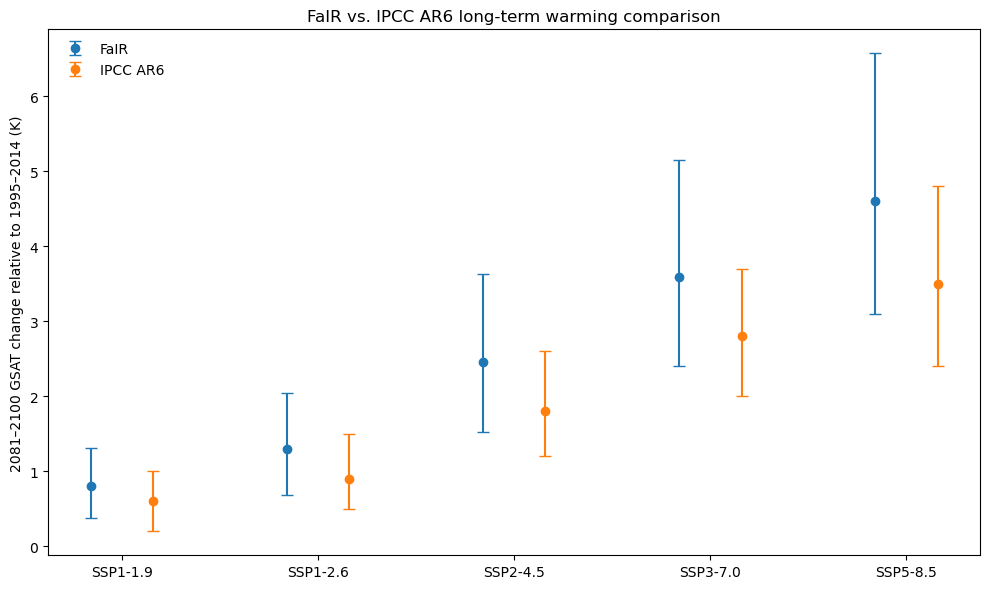

In [65]:


scenario_order = ["SSP1-1.9", "SSP1-2.6", "SSP2-4.5", "SSP3-7.0", "SSP5-8.5"]
plot_df = comparison_df.set_index("Scenario").loc[scenario_order].reset_index()

x = np.arange(len(plot_df))
width = 0.32

fair_mean = plot_df["FaIR mean (K)"].values
fair_low = plot_df["FaIR 5th percentile (K)"].values
fair_high = plot_df["FaIR 95th percentile (K)"].values

ar6_mean = plot_df["AR6 best estimate (K)"].values
ar6_low = plot_df["AR6 lower bound (K)"].values
ar6_high = plot_df["AR6 upper bound (K)"].values

pl.figure(figsize=(10, 6))

# FaIR points + range
pl.errorbar(
    x - width/2,
    fair_mean,
    yerr=[fair_mean - fair_low, fair_high - fair_mean],
    fmt='o',
    capsize=4,
    label='FaIR'
)

# AR6 points + range
pl.errorbar(
    x + width/2,
    ar6_mean,
    yerr=[ar6_mean - ar6_low, ar6_high - ar6_mean],
    fmt='o',
    capsize=4,
    label='IPCC AR6'
)

pl.xticks(x, plot_df["Scenario"])
pl.ylabel("2081–2100 GSAT change relative to 1995–2014 (K)")
pl.title("FaIR vs. IPCC AR6 long-term warming comparison")
pl.legend(frameon=False)
pl.tight_layout()
pl.show()

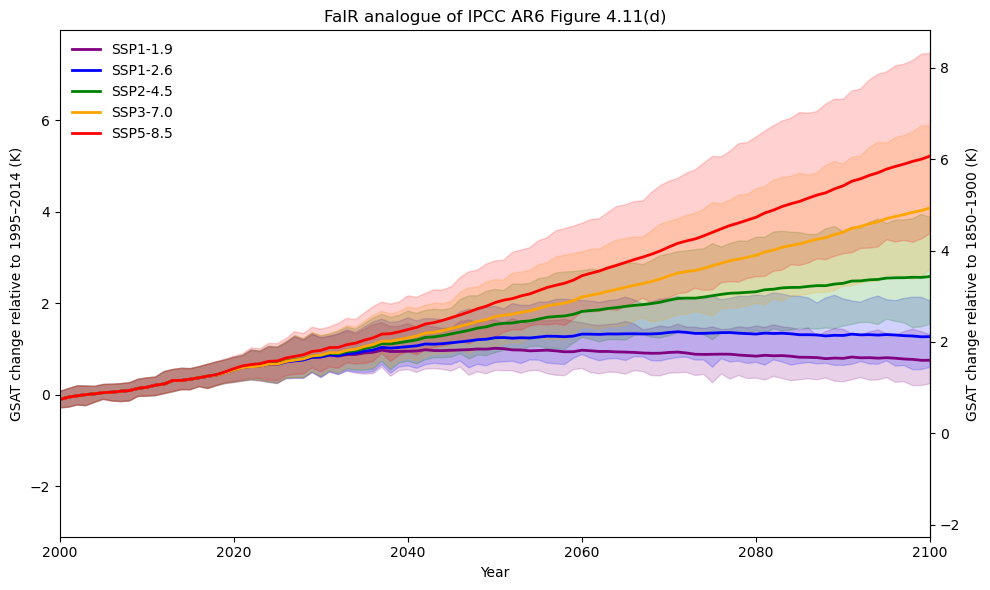

In [67]:
# FaIR panel-(d)-like figure for comparison with IPCC AR6 Figure 4.11
# Left axis: GSAT change relative to 1995-2014
# Right axis: shifted by +0.85 C to approximate warming relative to 1850-1900

priority_scenarios = {
    "ssp119": "SSP1-1.9",
    "ssp126": "SSP1-2.6",
    "ssp245": "SSP2-4.5",
    "ssp370": "SSP3-7.0",
    "ssp585": "SSP5-8.5",
}

scenario_colors = {
    "ssp119": "purple",
    "ssp126": "blue",
    "ssp245": "green",
    "ssp370": "orange",
    "ssp585": "red",
}

years = np.asarray(f.timebounds)

def fair_timeseries_rel_1995_2014(f_model, scenario):
    """
    Return surface temperature anomaly time series for one scenario,
    relative to the 1995-2014 mean.
    Output dimensions: timebounds x config
    """
    da = f_model.temperature.loc[dict(scenario=scenario, layer=0)].transpose("timebounds", "config")
    baseline = da.sel(timebounds=slice(1995, 2014)).mean(dim="timebounds")
    return da - baseline

fig, ax = pl.subplots(figsize=(10, 6))

# Plot one mean line + 5-95% range for each priority scenario
for scenario, label in priority_scenarios.items():
    da = fair_timeseries_rel_1995_2014(f, scenario)
    mean = da.mean(dim="config")
    p05 = da.quantile(0.05, dim="config")
    p95 = da.quantile(0.95, dim="config")

    ax.fill_between(
        years,
        p05.values,
        p95.values,
        color=scenario_colors[scenario],
        alpha=0.18
    )

    ax.plot(
        years,
        mean.values,
        color=scenario_colors[scenario],
        linewidth=2,
        label=label
    )

# Left axis: relative to 1995-2014
ax.set_xlim(2000, 2100)
ax.set_xlabel("Year")
ax.set_ylabel("GSAT change relative to 1995–2014 (K)")
ax.set_title("FaIR analogue of IPCC AR6 Figure 4.11(d)")
ax.legend(frameon=False)

# Right axis: shifted upward by 0.85 C to approximate relative to 1850-1900
warming_shift = 0.85
secax = ax.secondary_yaxis(
    "right",
    functions=(lambda y: y + warming_shift, lambda y: y - warming_shift)
)
secax.set_ylabel("GSAT change relative to 1850–1900 (K)")

pl.tight_layout()
pl.show()

## Comparison with IPCC AR6 Figure 4.11(d)

### What AR6 Figure 4.11(d) is
- AR6 WG1 **Figure 4.11** is a **multiple-lines-of-evidence** assessment figure for long-term **GSAT** change in **2081–2100 relative to 1995–2014** for the five priority SSP scenarios.
- In **panel (d)**, AR6 shows **time series** constructed from the assessed warming ranges rather than from one single raw model output.
- The AR6 caption states that the **time series in panel (d) are constructed by taking the average of the constrained CMIP6 ranges and the emulator ranges**.
- The AR6 caption also states that the **right-hand y-axis is shifted upward by 0.85°C**, which is the central estimate of observed warming for **1995–2014 relative to 1850–1900**.

### What my figure is
- My figure is **not the AR6 panel itself**.
- It is a **FaIR analogue inspired by AR6 Figure 4.11(d)**.
- I used the same five priority scenarios:
  - SSP1-1.9
  - SSP1-2.6
  - SSP2-4.5
  - SSP3-7.0
  - SSP5-8.5
- I plotted **FaIR temperature time series** for these scenarios using:
  - the **mean across FaIR configurations**
  - the **5th–95th percentile range** across FaIR configurations
- I used the **1995–2014 baseline** on the left axis so the figure is directly comparable in definition to the AR6 long-term GSAT metric.
- I added a **right-hand axis shifted by +0.85°C** to mimic the AR6 presentation of warming relative to **1850–1900**.
### How my figure was made
- I started from the multi-scenario FaIR run that uses the SSP scenarios and CMIP6-calibrated FaIR configurations. The FaIR SSP example notebook describes this setup as running SSP scenarios with **pre-calculated climate response calibrations from 66 CMIP6 models**.
- For each scenario, I:
  - extracted surface temperature (`layer = 0`)
  - rebased the time series to the **1995–2014 mean**
  - calculated the **mean**, **5th percentile**, and **95th percentile** across FaIR configurations
- I then plotted the scenario mean as a line and the 5th–95th range as shaded uncertainty.

### How this differs from the real AR6 panel (d)
- The real **AR6 Figure 4.11(d)** is an **assessment product**, not a direct FaIR output.
- AR6 panel (d) combines:
  - **constrained CMIP6 ranges**
  - **emulator ranges**
- My figure uses:
  - **FaIR only**
  - **CMIP6-calibrated FaIR configurations**
  - **stochastic variability** from the notebook setup
- Therefore, my figure is **not an exact reproduction** of AR6 panel (d), even though it is designed to follow the same overall framing.

### Why I still made this figure
- This figure is useful because it makes the comparison with AR6 more visual.
- My earlier **table** and **error-bar plot** already gave a direct numerical comparison for **2081–2100 relative to 1995–2014**.
- This new figure adds the **time-series view**, so I can compare the overall scenario behavior more directly with the AR6 panel-(d) style.

### What the comparison shows
- My FaIR figure reproduces the same overall **scenario ordering** as AR6:
  - lowest warming under **SSP1-1.9**
  - slightly higher warming under **SSP1-2.6**
  - intermediate warming under **SSP2-4.5**
  - stronger warming under **SSP3-7.0**
  - highest warming under **SSP5-8.5**
- The qualitative behavior is therefore consistent with AR6.
- However, my FaIR trajectories and ranges are generally **warmer than the AR6 assessed values**, especially for the higher-forcing scenarios, as already shown in my table and error-bar comparison.
- This means my setup captures the large-scale projection structure correctly, but it does not exactly match the AR6 assessed central estimates and ranges.

### Main interpretation
- Neither the AR6 panel (d) nor my figure should be described as a simple “raw FaIR figure.”
- The AR6 panel (d) is an **IPCC assessed synthesis** based on constrained CMIP6 and emulator ranges.
- My figure is a **FaIR-based analogue** built from one specific notebook setup.
- So the correct conclusion is:
  - my figure is **useful for comparison**
  - it is **structurally similar** to AR6 Figure 4.11(d)
  - but it is **not an exact re-creation** of the AR6 assessed panel